# Phase 8 — Analisis Sentimen Berbasis Leksikon
**PIC: Celine**

Pada fase ini, kita akan melakukan analisis sentimen terhadap artikel berita menggunakan dua pendekatan berbasis leksikon:
- **TextBlob**: library Python dengan sentiment analyzer default (bahasa Inggris).
- **InSet Lexicon**: leksikon sentimen untuk bahasa Indonesia.

Kita akan mengevaluasi kedua metode terhadap label manual (gold standard) yang sudah dibuat pada Phase 2.

## 1. Persiapan Lingkungan
Install library yang diperlukan (cukup jalankan sekali).
- `textblob` untuk analisis sentimen.
- `sklearn` untuk evaluasi.
- `matplotlib`, `seaborn` untuk visualisasi.

In [24]:
!pip install textblob seaborn scikit-learn
!pip install textblob seaborn scikit-learn
# !python -m textblob.download_corpora

# Import semua library yang diperlukan
import pandas as pd
import numpy as np
import re
import os
import urllib.request
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_recall_fscore_support

from textblob import TextBlob

print("✅ Semua library berhasil diimport.")

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: C:\Users\ASUS\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
✅ Semua library berhasil diimport.



[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: C:\Users\ASUS\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## 2. Load Dataset
Dataset yang digunakan adalah hasil dari Phase 4 (preprocessing): `dataset_lpdp_preprocessed.csv`.

Kolom penting:
- `content` → untuk TextBlob.
- `text_clean` → akan diproses ulang untuk InSet (tanpa stemming).
- Kolom label `Sentiment` → sebagai ground truth.

In [25]:
# Membaca dataset hasil preprocessing Phase 4
df = pd.read_csv('dataset_lpdp_preprocessed.csv')

print(f"Jumlah baris: {len(df)}")
print("\nNama kolom yang tersedia:")
print(df.columns.tolist())

# Langsung ambil kolom 'Sentiment' sebagai label
label_col = 'Sentiment'
print(f"\n✓ Kolom label yang digunakan: '{label_col}'")

# Convert semua label ke lowercase untuk matching dengan TextBlob & InSet
df[label_col] = df[label_col].str.lower()

print("\nDistribusi label manual:")
print(df[label_col].value_counts())

# Tentukan kolom teks untuk TextBlob (prioritaskan 'content' jika ada)
if 'content' in df.columns:
    textblob_col = 'content'
else:
    textblob_col = 'text_clean'
print(f"\n✓ TextBlob akan menggunakan kolom: '{textblob_col}'")

# Drop baris yang memiliki nilai kosong pada kolom teks atau label
df = df.dropna(subset=[textblob_col, 'text_clean', label_col])
print(f"\nSetelah drop NaN, tersisa {len(df)} baris.")

Jumlah baris: 1038

Nama kolom yang tersedia:
['doc_id', 'Title', 'Release Date', 'URL', 'Publisher', 'PiC', 'Valid?', 'Sentiment', 'Notes', 'Actual_URL', 'Content', 'label_4', 'label_name', 'text_clean']

✓ Kolom label yang digunakan: 'Sentiment'

Distribusi label manual:
Sentiment
positive    385
neutral     342
negative    311
Name: count, dtype: int64

✓ TextBlob akan menggunakan kolom: 'text_clean'

Setelah drop NaN, tersisa 1038 baris.


## 3. Preprocessing Khusus untuk InSet (Tanpa Stemming)
InSet Lexicon berisi kata dasar bahasa Indonesia. Jika pada Phase 4 dilakukan stemming, maka teks `text_clean` mungkin sudah berubah. Agar maksimal, kita buat kolom `text_inset` dengan preprocessing minimal:
- Lowercase
- Hapus tanda baca, angka, karakter non-alfabet
- Hapus spasi berlebih
- (Opsional) Normalisasi slang jika file `slang_id.csv` tersedia

In [26]:
def preprocess_for_inset(text):
    """Preprocessing ringan untuk InSet: lower, hapus non-alfabet, hapus spasi berlebih"""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)   # hanya huruf dan spasi
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_inset'] = df['text_clean'].apply(preprocess_for_inset)
print("Kolom 'text_inset' telah dibuat.")
print("\nContoh perbandingan:")
print(df[['text_clean', 'text_inset']].head(2))

Kolom 'text_inset' telah dibuat.

Contoh perbandingan:
                                          text_clean  \
0  cegah kolusi nepotisme program lpdp nilai keta...   
1  jakarta sekretaris komisi e dprd dki jakarta j...   

                                          text_inset  
0  cegah kolusi nepotisme program lpdp nilai keta...  
1  jakarta sekretaris komisi e dprd dki jakarta j...  


## 4. Unduh dan Muat InSet Lexicon
InSet Lexicon tersedia di repository GitHub [fajri91/InSet](https://github.com/fajri91/InSet). Kita unduh file `positive.tsv` dan `negative.tsv` (jika belum ada).

In [27]:
# URL raw data InSet
inset_url = "https://raw.githubusercontent.com/fajri91/InSet/master/"
files = ['positive.tsv', 'negative.tsv']

for filename in files:
    if not os.path.exists(filename):
        print(f"Mengunduh {filename}...")
        urllib.request.urlretrieve(inset_url + filename, filename)
        print(f"  -> Berhasil disimpan.")
    else:
        print(f"{filename} sudah ada.")

# Baca lexicon
positive_words = {}
negative_words = {}

with open('positive.tsv', 'r', encoding='utf-8') as f:
    next(f)  # Skip header line
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) >= 2:
            word = parts[0].lower()
            try:
                score = float(parts[1])
                positive_words[word] = score
            except ValueError:
                pass

with open('negative.tsv', 'r', encoding='utf-8') as f:
    next(f)  # Skip header line
    for line in f:
        parts = line.strip().split('\t')
        if len(parts) >= 2:
            word = parts[0].lower()
            try:
                score = float(parts[1])
                negative_words[word] = score
            except ValueError:
                pass

# Pastikan bobot negatif benar bernilai negatif
if all(score > 0 for score in negative_words.values()):
    negative_words = {k: -v for k, v in negative_words.items()}

print(f"\n✅ InSet Lexicon siap:")
print(f"   - Kata positif: {len(positive_words)}")
print(f"   - Kata negatif: {len(negative_words)}")

positive.tsv sudah ada.
negative.tsv sudah ada.

✅ InSet Lexicon siap:
   - Kata positif: 3607
   - Kata negatif: 6606


## 5. Hitung Polarity dengan TextBlob
TextBlob memberikan nilai `polarity` antara -1 (negatif) hingga 1 (positif). Kita klasifikasikan:
- `> 0` → positif
- `= 0` → netral
- `< 0` → negatif

In [28]:
def textblob_sentiment(text):
    blob = TextBlob(str(text))
    polarity = blob.sentiment.polarity
    if polarity > 0:
        label = 'positive'
    elif polarity < 0:
        label = 'negative'
    else:
        label = 'neutral'
    return polarity, label

print("Menjalankan TextBlob pada semua artikel...")
df[['tb_polarity', 'tb_label']] = df[textblob_col].apply(lambda x: pd.Series(textblob_sentiment(x)))
print("Selesai.")

print("\nStatistik Polarity TextBlob:")
print(f"Rata-rata: {df['tb_polarity'].mean():.4f}")
print(f"Min: {df['tb_polarity'].min():.4f}, Max: {df['tb_polarity'].max():.4f}")
print("\nDistribusi label TextBlob:")
print(df['tb_label'].value_counts())

Menjalankan TextBlob pada semua artikel...
Selesai.

Statistik Polarity TextBlob:
Rata-rata: 0.0067
Min: -0.6000, Max: 0.9000

Distribusi label TextBlob:
tb_label
neutral     560
negative    253
positive    225
Name: count, dtype: int64


## 6. Hitung Skor dengan InSet Lexicon
Prinsip: jumlah bobot kata positif + jumlah bobot kata negatif (bobot negatif sudah negatif). Hasil skor:
- `> 0` → positif
- `= 0` → netral
- `< 0` → negatif

In [29]:
def inset_sentiment(text):
    tokens = text.split()
    score = 0.0
    for token in tokens:
        if token in positive_words:
            score += positive_words[token]
        if token in negative_words:
            score += negative_words[token]   # sudah negatif
    if score > 0:
        label = 'positive'
    elif score < 0:
        label = 'negative'
    else:
        label = 'neutral'
    return score, label

print("Menjalankan InSet pada kolom text_inset...")
df[['inset_score', 'inset_label']] = df['text_inset'].apply(lambda x: pd.Series(inset_sentiment(x)))
print("Selesai.")

print("\nStatistik Skor InSet:")
print(f"Rata-rata: {df['inset_score'].mean():.4f}")
print(f"Min: {df['inset_score'].min():.4f}, Max: {df['inset_score'].max():.4f}")
print("\nDistribusi label InSet:")
print(df['inset_label'].value_counts())

Menjalankan InSet pada kolom text_inset...
Selesai.

Statistik Skor InSet:
Rata-rata: 29.6368
Min: -193.0000, Max: 547.0000

Distribusi label InSet:
inset_label
positive    744
negative    281
neutral      13
Name: count, dtype: int64


## 7. Evaluasi TextBlob vs Label Manual
Kita bandingkan prediksi TextBlob dengan label manual menggunakan:
- Accuracy
- Classification Report (precision, recall, f1-score per kelas)
- Confusion Matrix

EVALUASI TEXTBLOB

✅ Accuracy: 0.3430 (34.30%)

📋 Classification Report:
              precision    recall  f1-score   support

    negative       0.34      0.27      0.30       311
     neutral       0.31      0.51      0.39       342
    positive       0.42      0.25      0.31       385

    accuracy                           0.34      1038
   macro avg       0.36      0.34      0.33      1038
weighted avg       0.36      0.34      0.33      1038



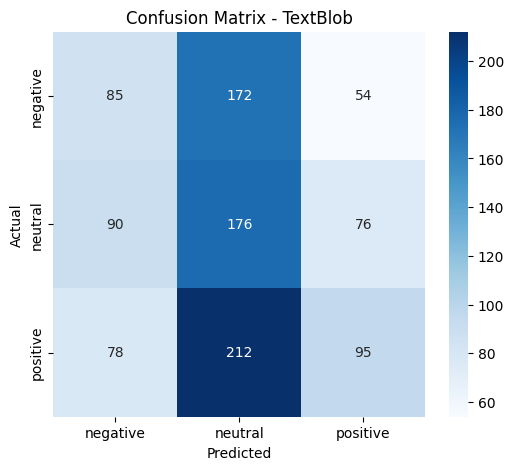

In [30]:
y_true = df[label_col]
y_pred_tb = df['tb_label']

# Ambil label unik yang ada di data
unique_labels = sorted(list(set(y_true.unique()) | set(y_pred_tb.unique())))

print("="*50)
print("EVALUASI TEXTBLOB")
print("="*50)
acc_tb = accuracy_score(y_true, y_pred_tb)
print(f"\n✅ Accuracy: {acc_tb:.4f} ({acc_tb*100:.2f}%)")

print("\n📋 Classification Report:")
print(classification_report(y_true, y_pred_tb, labels=unique_labels))

# Confusion Matrix
cm_tb = confusion_matrix(y_true, y_pred_tb, labels=unique_labels)
plt.figure(figsize=(6,5))
sns.heatmap(cm_tb, annot=True, fmt='d', cmap='Blues',
            xticklabels=unique_labels,
            yticklabels=unique_labels)
plt.title('Confusion Matrix - TextBlob')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 8. Evaluasi InSet vs Label Manual
Evaluasi yang sama terhadap hasil InSet Lexicon.

EVALUASI INSET LEXICON

✅ Accuracy: 0.3805 (38.05%)

📋 Classification Report:
              precision    recall  f1-score   support

    negative       0.34      0.31      0.32       311
     neutral       0.46      0.02      0.03       342
    positive       0.40      0.76      0.52       385

    accuracy                           0.38      1038
   macro avg       0.40      0.36      0.29      1038
weighted avg       0.40      0.38      0.30      1038



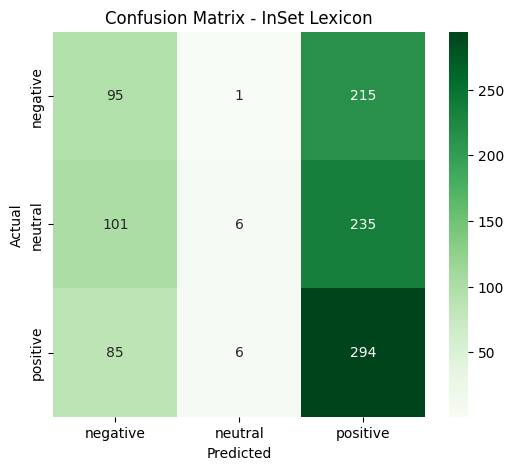

In [31]:
y_pred_inset = df['inset_label']

print("="*50)
print("EVALUASI INSET LEXICON")
print("="*50)
acc_inset = accuracy_score(y_true, y_pred_inset)
print(f"\n✅ Accuracy: {acc_inset:.4f} ({acc_inset*100:.2f}%)")

print("\n📋 Classification Report:")
print(classification_report(y_true, y_pred_inset, labels=unique_labels))

# Confusion Matrix
cm_inset = confusion_matrix(y_true, y_pred_inset, labels=unique_labels)
plt.figure(figsize=(6,5))
sns.heatmap(cm_inset, annot=True, fmt='d', cmap='Greens',
            xticklabels=unique_labels,
            yticklabels=unique_labels)
plt.title('Confusion Matrix - InSet Lexicon')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [32]:
print("Jumlah kata positive:", len(positive_words))
print("Jumlah kata negative:", len(negative_words))

# Lihat sample text_inset
print("\nSample text_inset:")
print(df['text_inset'].head(3).values)

# Lihat sample score sebelum jadi label
print("\nSample inset_score:")
print(df['inset_score'].head(10).values)

# Cek ada berapa yang score negatif
print(f"\nTotal negative scores: {(df['inset_score'] < 0).sum()}")
print(f"Total neutral scores: {(df['inset_score'] == 0).sum()}")
print(f"Total positive scores: {(df['inset_score'] > 0).sum()}")

Jumlah kata positive: 3607
Jumlah kata negative: 6606

Sample text_inset:
['cegah kolusi nepotisme program lpdp nilai ketat seleksi jakarta sekretaris komisi e dprd dki jakarta justin adrian untayana nilai seleksi terima program beasiswa lembaga kelola dana didik lpdp versi jakarta ketat cegah praktik kolusi nepotisme dalam main adil jurus kolusi nepotisme laku istimewa justin jakarta selasa seleksi terima program ketat isu lpdp hangat komitmen terima kontribusi negara daerah selesai studi karakter komitmen terima beasiswa bangun jakarta selesai studi berangkat negara tuju nilai akademik timbang utama tentu berangkat negeri justin sisi sambung perintah provinsi pemprov dki jakarta meta jalur akademik terima lpdp lulus partisipasi bangun jakarta sektor mahasiswa sektor sektor sesuai bidang studi kuliah negeri justin baca lpdp jakarta ganggu anggar bansos didik gubernur dki jakarta pramono anung wibowo target program beasiswa lpdp versi pemprov dki jakarta laksana salah canang lpdp jakar

## 9. Perbandingan Kinerja Kedua Metode
Kita hitung metrik agregat (weighted) dan bandingkan dalam bentuk tabel serta grafik batang.

PERBANDINGAN METRIK
     Method  Accuracy  Precision (weighted)  Recall (weighted)  \
0  TextBlob    0.3430                0.3608             0.3430   
1     InSet    0.3805                0.3999             0.3805   

   F1-Score (weighted)  
0               0.3344  
1               0.3005  


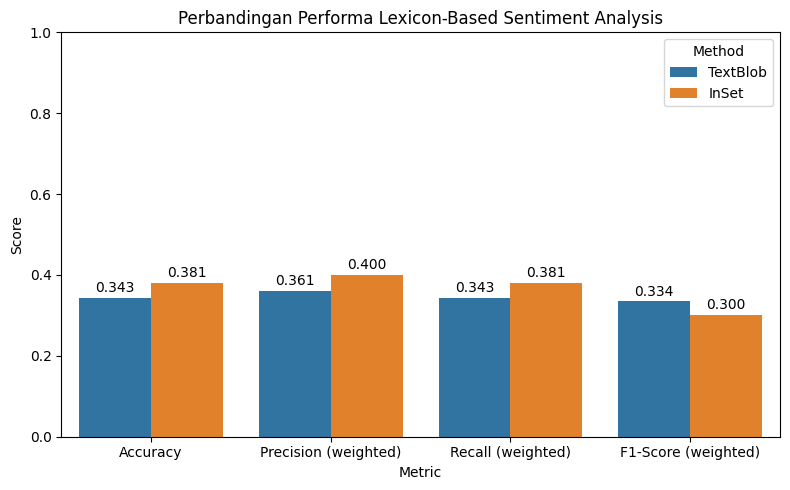

In [33]:
def get_weighted_metrics(y_true, y_pred, label_list):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', labels=label_list)
    return acc, p, r, f1

metrics_tb = get_weighted_metrics(y_true, y_pred_tb, unique_labels)
metrics_inset = get_weighted_metrics(y_true, y_pred_inset, unique_labels)

comparison = pd.DataFrame({
    'Method': ['TextBlob', 'InSet'],
    'Accuracy': [metrics_tb[0], metrics_inset[0]],
    'Precision (weighted)': [metrics_tb[1], metrics_inset[1]],
    'Recall (weighted)': [metrics_tb[2], metrics_inset[2]],
    'F1-Score (weighted)': [metrics_tb[3], metrics_inset[3]]
})

print("="*50)
print("PERBANDINGAN METRIK")
print("="*50)
print(comparison.round(4))

# Visualisasi
fig, ax = plt.subplots(figsize=(8,5))
comparison_melted = comparison.melt(id_vars='Method', var_name='Metric', value_name='Score')
sns.barplot(data=comparison_melted, x='Metric', y='Score', hue='Method', ax=ax)
ax.set_ylim(0,1)
ax.set_title('Perbandingan Performa Lexicon-Based Sentiment Analysis')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=2)
plt.tight_layout()
plt.show()

## 10. Simpan Hasil Analisis
Terakhir, simpan dataframe yang sudah dilengkapi dengan hasil sentimen ke file CSV untuk dokumentasi.

In [34]:
output_cols = [textblob_col, 'text_inset', label_col, 
               'tb_polarity', 'tb_label', 
               'inset_score', 'inset_label']
df_output = df[output_cols].copy()
df_output.to_csv('phase8_hasil_analisis_sentimen.csv', index=False, encoding='utf-8')
print("✅ File hasil disimpan: phase8_hasil_analisis_sentimen.csv")

# Tampilkan 5 baris pertama
df_output.head()

✅ File hasil disimpan: phase8_hasil_analisis_sentimen.csv


,text_clean,text_inset,Sentiment,tb_polarity,tb_label,inset_score,inset_label
0,cegah kolusi nepotisme program lpdp nilai keta...,cegah kolusi nepotisme program lpdp nilai keta...,negative,0.166667,positive,17.0,positive
1,jakarta sekretaris komisi e dprd dki jakarta j...,jakarta sekretaris komisi e dprd dki jakarta j...,negative,0.000000,neutral,23.0,positive
2,lpdp program beasiswa jalan menteri uang beasi...,lpdp program beasiswa jalan menteri uang beasi...,negative,0.000000,neutral,28.0,positive
3,dirjen ahu anak ds alumni lpdp status wni huku...,dirjen ahu anak ds alumni lpdp status wni huku...,negative,0.000000,neutral,-43.0,negative
4,dirut beasiswa lpdp sifat inklusif fokus cari ...,dirut beasiswa lpdp sifat inklusif fokus cari ...,positive,0.280000,positive,57.0,positive


## Kesimpulan
Dari hasil evaluasi, kita dapat melihat:
- **TextBlob** cenderung lebih cocok untuk teks bahasa Inggris; untuk bahasa Indonesia akurasinya mungkin lebih rendah.
- **InSet Lexicon** dirancang khusus untuk bahasa Indonesia, tetapi performanya masih terbatas karena model ini hanya menjumlahkan skor kata dan tidak memahami konteks berita.
- Analisis confusion matrix membantu melihat kesalahan klasifikasi pada kelas tertentu (misal netral sering salah diklasifikasikan).

Secara singkat:
- Hasil TextBlob buruk karena bukan model bahasa Indonesia.
- Hasil InSet lebih baik, tetapi masih belum cukup bagus untuk berita LPDP karena banyak teks netral dan konteks yang kompleks.
- Jika ingin hasil lebih baik, perlu metode yang memahami konteks Bahasa Indonesia, bukan hanya hitung skor kata.